## 1. What this notebook computes

The author's metric has one free function, $a_4(x_4)$, and the Einstein-Lovelock
field equations decide which **source** (energy density and pressures of matter)
can produce it. The Revision record of these equations shows that their left-hand
sides do not depend on the hidden coordinate $x_8$ and obey one algebraic identity.
So every admissible source must satisfy three conditions:

- **C1**: no component of the source depends on $x_8$ (and the mixed component
  $q_{48}$ is zero);
- **C2**: $p_3 + p_t = 2p_8$ (3-space pressure plus extra-time pressure equals
  twice the hidden-direction pressure);
- **C3**: for the linear member $a_4 = AHx_4 + a_0$ (the history used by the
  Kohn-Sham computations): $p_3 = p_t = p_8$ and a constant energy density.

This notebook

- derives C1, C2 and C3 with sympy from the Lovelock components of the record;
- reads the 75 Kohn-Sham ground states of the Revision record (their profiles
  along the hidden coordinate and their integrals);
- evaluates C1, C2 (point by point and after integration over $x_8$) and C3 on
  every state and reproduces every number of the five checks of the record
  `ks-source-conditions.json`;
- concludes, as the record does, that no recorded Kohn-Sham state is an
  admissible source, so that the Kohn-Sham history $a_4 = AHx_4$ is a
  **prescribed background** (the gas is a test field without back-reaction);
- draws seven teaching plots. It takes about fifteen seconds.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 17a (The source conditions of the a4 equations on the recorded Kohn-Sham states)
is the file `Revision/textbook/notebooks/17a_source_conditions.ipynb` of the repository
Dirac_claude. It derives with sympy, from the Lovelock components stored in the Revision
record of the a4 field equations, the three conditions that every source of the author's
metric must meet (C1: no dependence on the hidden coordinate x8; C2: p3 + p_t = 2 p8; C3:
for the linear member a4 = A H x4, equal pressures and a constant energy density). It
then evaluates the three conditions on the 75 committed Kohn-Sham ground states of
dirac16complex, reproduces every number of the five checks of the Revision record
ks-source-conditions.json, shows that no recorded Kohn-Sham state is an admissible
source, so that the Kohn-Sham history is a prescribed background, and draws seven
teaching plots. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 17a_source_conditions.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 17a_source_conditions.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
17a_source_conditions.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/17a.captions.json`
- `Revision/textbook/figures/17a_1_rho_profiles.png`
- `Revision/textbook/figures/17a_2_c1_map.png`
- `Revision/textbook/figures/17a_3_violation_profiles.png`
- `Revision/textbook/figures/17a_4_c2_map.png`
- `Revision/textbook/figures/17a_5_three_points.png`
- `Revision/textbook/figures/17a_6_integrated_ratio.png`
- `Revision/textbook/figures/17a_7_history_integrals.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 16 CHECKS PASSED (notebook 17a)

and the notebook must show 7 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/17a_source_conditions.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming ks-source-conditions.json or a profile file: the notebook
  reads the Revision records of the repository. Run it inside the folder
  Revision/textbook/notebooks of a complete copy of the repository made with git clone,
  not on a copy of the notebook file alone.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 17a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 17a (The source conditions of the a4 equations on the recorded Kohn-Sham
# states) is the file Revision/textbook/notebooks/17a_source_conditions.ipynb of the
# repository Dirac_claude. It derives with sympy, from the Lovelock components stored in
# the Revision record of the a4 field equations, the three conditions that every source
# of the author's metric must meet (C1: no dependence on the hidden coordinate x8; C2: p3
# + p_t = 2 p8; C3: for the linear member a4 = A H x4, equal pressures and a constant
# energy density). It then evaluates the three conditions on the 75 committed Kohn-Sham
# ground states of dirac16complex, reproduces every number of the five checks of the
# Revision record ks-source-conditions.json, shows that no recorded Kohn-Sham state is an
# admissible source, so that the Kohn-Sham history is a prescribed background, and draws
# seven teaching plots. It needs a computer with Windows 11, macOS or Linux, an internet
# connection for the installation, the program Git, and Python 3.12 or newer (the
# notebooks were built with Python 3.14.5) with these packages at exactly these versions:
# numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
# 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
# imports numpy, sympy and matplotlib; the other packages run Jupyter, the program that
# shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 17a_source_conditions.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 17a_source_conditions.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 17a_source_conditions.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/17a.captions.json
# - Revision/textbook/figures/17a_1_rho_profiles.png
# - Revision/textbook/figures/17a_2_c1_map.png
# - Revision/textbook/figures/17a_3_violation_profiles.png
# - Revision/textbook/figures/17a_4_c2_map.png
# - Revision/textbook/figures/17a_5_three_points.png
# - Revision/textbook/figures/17a_6_integrated_ratio.png
# - Revision/textbook/figures/17a_7_history_integrals.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 16 CHECKS PASSED (notebook 17a)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/17a_source_conditions.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming ks-source-conditions.json or a profile file: the notebook
#   reads the Revision records of the repository. Run it inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository made with git clone,
#   not on a copy of the notebook file alone.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "17a"  # this notebook: chapter 17, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 17a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** (the author's names): $x_1, x_2, x_3$ = ordinary 3-space,
  which inflates (scale factor $e^{a_4}\sin^{1/6}z$); $x_4$ = the time;
  $x_5, x_6, x_7$ = the three **extra times**, which **deflate exponentially**
  (scale factor $e^{-a_4}\sin^{1/6}z$, with $a_4$ increasing); $x_8$ = the hidden
  space direction, with $z = 6Hx_8$ between $0$ and $\pi/2$.
- **Hidden coordinate** $y = \ln(\sin z)/(6H)$: another way to number the points
  of the hidden direction. $y = 0$ is the end $z = \pi/2$ (the **brane**), and
  $y \to -\infty$ is the end $z \to 0$ (the **tip**). The computations stop at
  $y = -L = -3$ (the **tip cutoff**). Since $y$ grows when $x_8$ grows, "depends
  on $y$" and "depends on $x_8$" mean the same thing.
- **Energy-momentum tensor** $T^\mu{}_\nu$: an $8 \times 8$ table at each point
  that says how much energy and momentum matter has and how they flow. For our
  sources it is diagonal: $T = \mathrm{diag}(p_3, p_3, p_3, -\rho, p_t, p_t, p_t,
  p_8)$ in the order $x_1, \dots, x_8$, plus a possible mixed entry $q_{48}$ (row
  $x_4$, column $x_8$).
- **Energy density** $\rho$ and **pressures** $p_3$ (each direction of 3-space),
  $p_t$ (each extra time), $p_8$ (the hidden direction).
- **Source**: the matter whose $T$ stands on the right-hand side of the field
  equations. **Admissible source**: a $T$ for which the field equations of the
  author's metric can hold.
- **Profile**: a component of $T$ as a function of $y$, stored at the 151 points
  $y = -3, -2.98, \dots, 0$. **Proper density**: per unit of proper 7-volume
  (the volume that rulers measure). The diagonal components $T^\mu{}_\mu$ (one
  index up, one down) are the same in the coordinates and in the frame of rulers,
  so the profiles are directly the $\rho$ and $p$ of the field equations.
- **Kohn-Sham state**: a many-fermion state of dirac16complex computed with the
  Kohn-Sham method (density functional theory) by the Rust solver of the Revision
  record. A state is labelled by its particle number $N$ (8, 136 or 688), its
  self-coupling $\lambda$ ($0$, $\pm\lambda_1$, $\pm\lambda_2$) and its **slice**
  $a_{4,0}$, the value of $a_4$ at which it was computed ($0, 0.5, 1, 1.5, 2$).
  The name `N136_lamp2_a20` means $N = 136$, $\lambda = +\lambda_2$,
  $a_{4,0} = 2.0$ (`lamm1` is $-\lambda_1$, `lam0` is $\lambda = 0$).
- **History**: the sequence of slices along $a_4 = AHx_4$ with $A = 1$.
  **Linear member**: this choice of $a_4$, a straight line in $x_4$.
- **Prescribed background**: a metric that is GIVEN, not solved for. A field that
  moves in it but whose own gravity is ignored is a **test field**; ignoring its
  gravity means ignoring its **back-reaction** on the metric.
- **Integral over the patch**: $2\,\mathrm{Vol}_7\int_{-3}^{0} e^{6Hy}\,X\,dy$, the
  total amount of $X$ in the computed region. Here $\mathrm{Vol}_7 = \ell^3 v_t$ is
  the coordinate volume of the six directions $x_1, x_2, x_3$ (a box of side
  $\ell$) and $x_5, x_6, x_7$ (coordinate volume $v_t$); times $e^{6Hy}\,dy$ it is
  the proper 7-volume of a thin slab of the hidden direction. The factor 2 counts
  the mirror copy of the ASSUMED $Z_2$ brane.
- **max|T|**: the largest absolute value of $\rho$, $p_3$, $p_t$, $p_8$ of a state
  over all $y$; we divide by it to compare states of very different size.
- **Status labels**: PROVED (exact), COMPUTED (numerical), ASSUMED (a choice),
  OPEN (not known).
- Units: $H = 1$, $m = 1$ (the fermion mass): lengths in units of $1/H$, energy
  densities and pressures in units of $m^8$, integrals over the patch (energies)
  in units of $m$.

## 4. The physical and mathematical situation

The author's metric (order $x_1, \dots, x_8$, $z = 6Hx_8$) is diagonal with entries
$e^{2a_4}\sin^{1/3}z$ (three times), $-1$, $-e^{-2a_4}\sin^{1/3}z$ (three times),
$\cot^2 z$. The Einstein-Lovelock field equations are

$$\sum_{k=1}^{3}\alpha_k E_{(k)}{}^{\mu}{}_{\nu} + \Lambda\,\delta^\mu_\nu =
\kappa\,T^\mu{}_\nu ,$$

with the Lovelock tensors $E_{(1)}$ (Einstein), $E_{(2)}$ (Gauss-Bonnet), $E_{(3)}$
(third order), couplings $\alpha_k$, cosmological constant $\Lambda$ and strength of
gravity $\kappa$. The Revision record gives every component of the left-hand side
as a polynomial in $a_4'$, $a_4''$ and $H$ (the prime is $d/dx_4$). The diagonal
components give four equations:

$$\textstyle\sum_k\alpha_kE_{(k)}{}^{x_4}{}_{x_4} + \Lambda = -\kappa\rho,\quad
\sum_k\alpha_kE_{(k)}{}^{x_1}{}_{x_1} + \Lambda = \kappa p_3,$$
$$\textstyle\sum_k\alpha_kE_{(k)}{}^{x_5}{}_{x_5} + \Lambda = \kappa p_t,\quad
\sum_k\alpha_kE_{(k)}{}^{x_8}{}_{x_8} + \Lambda = \kappa p_8 .$$

The left-hand sides contain no $x_8$, so the right-hand sides cannot either (C1).
The left-hand sides obey $E^{x_1}{}_{x_1} + E^{x_5}{}_{x_5} = 2E^{x_8}{}_{x_8}$
for every $k$; adding the $x_1$ and $x_5$ equations and subtracting twice the $x_8$
equation gives $\kappa(p_3 + p_t - 2p_8) = 0$ (C2; $\Lambda$ cancels because
$\Lambda + \Lambda - 2\Lambda = 0$). For $a_4 = AHx_4 + a_0$ we have $a_4' = AH$
(a constant) and $a_4'' = 0$; then the $x_1$, $x_5$ and $x_8$ left-hand sides
coincide and none of them changes with $x_4$ (C3).

The Kohn-Sham computations of the Revision record use exactly this linear member:
they solve the Kohn-Sham equations of dirac16complex at five slices $a_{4,0}$ of the
history $a_4 = Hx_4$ (instantaneous, adiabatic states, in the good sector without
extra-time momenta, with the ASSUMED $Z_2$ mirror at the brane and a tip cutoff at
$y = -3$). The question of this notebook: is the energy-momentum tensor of these
states an admissible source, so that the history would be a solution of the
coupled equations? The answer of the record is no; we check every number of it.

## 5. The Revision records and the helpers that read them

The next cell imports the packages and defines three helpers. `read_json` reads a
JSON file of the repository. `record_entry` finds a check by its name in a Revision
report. `reproduces` is a check that passes only when this notebook's own result
holds AND the named checks of the report have the verdict PASS; it prints the
report file and the check names. The cell then reads the record on the Kohn-Sham
source conditions, prints its conclusion and checks that its five checks passed.

In [2]:
import csv  # reads tables stored as CSV files (comma-separated values)

import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra with symbols

SOURCE_REPORT = "Revision/field_equations_a4/reports/ks-source-conditions.json"
EQUATIONS = "Revision/field_equations_a4/a4-equations.json"  # the a4 equations
PY_A4 = "Revision/field_equations_a4/reports/python-a4-report.json"  # sympy checks
WL_A4 = "Revision/field_equations_a4/reports/wolfram-a4-report.json"  # Wolfram
GROUND = "Revision/kohn_sham/results/ground"  # the 75 Kohn-Sham ground states


def read_json(relative):
    """Read a JSON file of the repository (a Revision record)."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


def record_entry(report_file, name):
    """The entry {name, verdict, detail} of a check of a report, None if absent."""
    for entry in read_json(report_file)["checks"]:
        if entry["name"] == name:
            return entry
    return None


def reproduces(condition, name, report_file, record_names):
    """A check that also requires the named checks of the report to be PASS."""
    found = all((record_entry(report_file, n) or {}).get("verdict") == "PASS"
                for n in record_names)
    check(condition and found, name,
          record=f"{report_file}, check {', '.join(record_names)}")


source_record = read_json(SOURCE_REPORT)
summary = source_record["summary"]  # how many checks the record has, how many pass
report("checks of the record ks-source-conditions.json",
       f"{summary['pass']} of {summary['checks']} PASS")
say("its conclusion: " + source_record["conclusion"])
check(summary == {"checks": 5, "pass": 5, "fail": 0},
      "the record on the Kohn-Sham source conditions has 5 checks, all PASS")

RESULT checks of the record ks-source-conditions.json = 5 of 5 PASS
its conclusion: No Kohn-Sham state recorded in Revision/kohn_sham is an admissible source
    of the author's metric: C1 and C2 fail for every nonzero state (C2 also after
    integration over x8), and the Kohn-Sham history uses the linear member as a
    prescribed background, without back-reaction.
PASS the record on the Kohn-Sham source conditions has 5 checks, all PASS


## 6. The three conditions, derived from the a4 equations

The record stores each Lovelock component as a formula in the Wolfram Language:
`ad1` stands for $a_4'$, `ad2` for $a_4''$, `^` for a power. The next cell turns
the components $x_1x_1$, $x_4x_4$, $x_5x_5$, $x_8x_8$ and $x_4x_8$ of
$E_{(1)}, E_{(2)}, E_{(3)}$ into sympy expressions and prints those of Einstein's
tensor $E_{(1)}$ (they are the left-hand sides of Einstein gravity).

In [3]:
equations = read_json(EQUATIONS)
ad1, ad2 = sp.symbols("ad1 ad2", real=True)  # a4' and a4'' (the record's names)
H = sp.symbols("H", positive=True)  # the constant H of the metric
NAMES = {"ad1": ad1, "ad2": ad2, "H": H}  # how the record's names become symbols


def parse(text):
    """A formula of the record (Wolfram Language text) as a sympy expression."""
    return sp.sympify(text.replace("^", "**"), locals=NAMES)


COMPONENTS = ("x1x1", "x4x4", "x5x5", "x8x8", "x4x8")
E = {k: {c: parse(equations["lovelockTensors"][f"E{k}"][c]["input"])
         for c in COMPONENTS}
     for k in (1, 2, 3)}  # E[k][component]: the Lovelock tensor of order k
for c in COMPONENTS:
    say(f"E_(1)^{c[:2]}_{c[2:]} = {E[1][c]}")

E_(1)^x1_x1 = 15*H**2 - 3*ad1**2 + ad2
E_(1)^x4_x4 = 21*H**2 + 3*ad1**2
E_(1)^x5_x5 = 15*H**2 - 3*ad1**2 - ad2
E_(1)^x8_x8 = 15*H**2 - 3*ad1**2
E_(1)^x4_x8 = 0


The next cell checks the three conditions on the left-hand sides, for all three
Lovelock orders.

- C1: every component contains only the symbols $a_4'$, $a_4''$, $H$ (no $x_8$,
  not even through $\cot z$), and the mixed $x_4x_8$ component is zero, so the
  source must have $q_{48} = 0$.
- C2: $E^{x_1}{}_{x_1} + E^{x_5}{}_{x_5} - 2E^{x_8}{}_{x_8}$ expands to zero.
- C3: with $a_4'' = 0$ the $x_1$, $x_5$, $x_8$ components are equal, and the
  $x_4$ component contains $a_4'$ and $H$ only (constant when $a_4' = AH$).

In [4]:
allowed = {ad1, ad2, H}  # the only symbols a left-hand side may contain
no_x8 = all(E[k][c].free_symbols <= allowed for k in E for c in COMPONENTS)
reproduces(no_x8 and all(E[k]["x4x8"] == 0 for k in E),
           "C1: the left-hand sides are free of x8 and the x4-x8 one is 0",
           WL_A4, ["P1_structure", "P2_structure", "P3_structure"])
identity = [sp.expand(E[k]["x1x1"] + E[k]["x5x5"] - 2 * E[k]["x8x8"]) for k in E]
say(f"E^x1_x1 + E^x5_x5 - 2 E^x8_x8 for k = 1, 2, 3: {identity}")
reproduces(all(value == 0 for value in identity),
           "C2: E^x1_x1 + E^x5_x5 = 2 E^x8_x8 for every order k",
           WL_A4, ["algebraic_identity_x1_plus_x5_minus_2x8"])
linear = {ad2: 0}  # the linear member: a4'' = 0 (and a4' = A H, a constant)
equal = all(sp.expand((E[k]["x1x1"] - E[k]["x8x8"]).subs(linear)) == 0
            and sp.expand((E[k]["x5x5"] - E[k]["x8x8"]).subs(linear)) == 0
            for k in E)
rho_side = all(E[k]["x4x4"].free_symbols <= {ad1, H} for k in E)
reproduces(equal and rho_side,
           "C3: for a4'' = 0 the pressures are equal and rho is constant",
           PY_A4, ["linear_member_equal_pressures"])

PASS C1: the left-hand sides are free of x8 and the x4-x8 one is 0
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    P1_structure, P2_structure, P3_structure
E^x1_x1 + E^x5_x5 - 2 E^x8_x8 for k = 1, 2, 3: [0, 0, 0]
PASS C2: E^x1_x1 + E^x5_x5 = 2 E^x8_x8 for every order k
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    algebraic_identity_x1_plus_x5_minus_2x8
PASS C3: for a4'' = 0 the pressures are equal and rho is constant
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    linear_member_equal_pressures


## 7. The recorded Kohn-Sham states and the hidden coordinate

The next cell reads the 75 profile files of the record (one per state; columns
`y`, `rho`, `p3`, `p_t`, `p8` among others), the table of integrals, and the
parameters of the computations. For every state it computes max|T|, the largest
absolute value of the four components, and sorts the states into those with a
nonzero tensor and those with $T = 0$ everywhere (no source at all). It also prints
what the Kohn-Sham theory record says about the mixed component $q_{48}$ (there
written $T^{x_4}{}_y$): it vanishes for every eigen-orbital, so the Kohn-Sham states
meet the part $q_{48} = 0$ of C1; the question is the $x_8$ dependence.

In [5]:
COLUMNS = ("rho", "p3", "p_t", "p8")  # the four diagonal components of the source


def read_profile(path):
    """A profile table as a dictionary: column name -> numpy array (151 values)."""
    data = np.genfromtxt(path, delimiter=",", names=True)
    return {name: data[name] for name in data.dtype.names}


files = sorted(repository_file(f"{GROUND}/profiles").glob("*.csv"),
               key=lambda path: path.name)  # in alphabetical order, as the record
profiles = {path.stem: read_profile(path) for path in files}
with repository_file(f"{GROUND}/emt-integrals.csv").open(
        encoding="utf-8", newline="") as handle:
    integrals = {row["id"]: row for row in csv.DictReader(handle)}
physics = read_json("Revision/kohn_sham/results/parameters.json")["physics"]
scale = {sid: float(max(np.max(np.abs(prof[c])) for c in COLUMNS))
         for sid, prof in profiles.items()}  # max|T| of every state
zero = [sid for sid in profiles if scale[sid] == 0.0]  # T = 0 everywhere
nonzero = [sid for sid in profiles if scale[sid] > 0.0]
y = profiles["N136_lam0_a10"]["y"]  # the grid of the hidden coordinate
same_grid = all(np.array_equal(prof["y"], y) for prof in profiles.values())
report("states read", len(profiles))
report("states with a nonzero tensor", len(nonzero))
report("grid of y", f"{len(y)} points from {y[0]:g} to {y[-1] + 0.0:g}, "
       f"step {y[1] - y[0]:.2f}")
report("H, tip cutoff L, Vol_7", f"{physics['H']:g}, {physics['L_tipCutoff']:g}, "
       f"{physics['Vol7']:.6g}")
say("ks-theory.json, emt.offDiagonal: "
    + read_json("Revision/kohn_sham/ks-theory.json")["emt"]["offDiagonal"])
check(len(profiles) == 75 and len(nonzero) == 70 and len(zero) == 5 and same_grid
      and sorted(integrals) == sorted(profiles),
      "75 states on one grid (70 nonzero, 5 zero); every state has its integrals")

RESULT states read = 75
RESULT states with a nonzero tensor = 70
RESULT grid of y = 151 points from -3 to 0, step 0.02
RESULT H, tip cutoff L, Vol_7 = 1, 3, 15875.2
ks-theory.json, emt.offDiagonal: T^x4_y = 0 for eigen-orbitals (K_x4y = P (eps - v/2)
    c_o, c_o = 0)
PASS 75 states on one grid (70 nonzero, 5 zero); every state has its integrals


The next cell draws two pictures. Left: the hidden coordinate
$y = \ln(\sin z)/(6H)$ against $z = 6Hx_8$ (logarithmic horizontal axis), with the
computed patch from the tip cutoff $y = -3$ to the brane $y = 0$; the cutoff sits
at $z = \arcsin(e^{-18})$, so the patch covers almost all of the hidden direction.
Right: the energy density $\rho(y)$, divided by max|T|, of the state $N = 136$,
$\lambda = 0$ at the five slices (logarithmic vertical axis; the cell first checks
that $\rho$ is positive at every point, so that a logarithmic axis can show it).
An admissible source would be a horizontal line (C1).

PASS N = 136, lambda = 0: rho is positive at every point of every slice


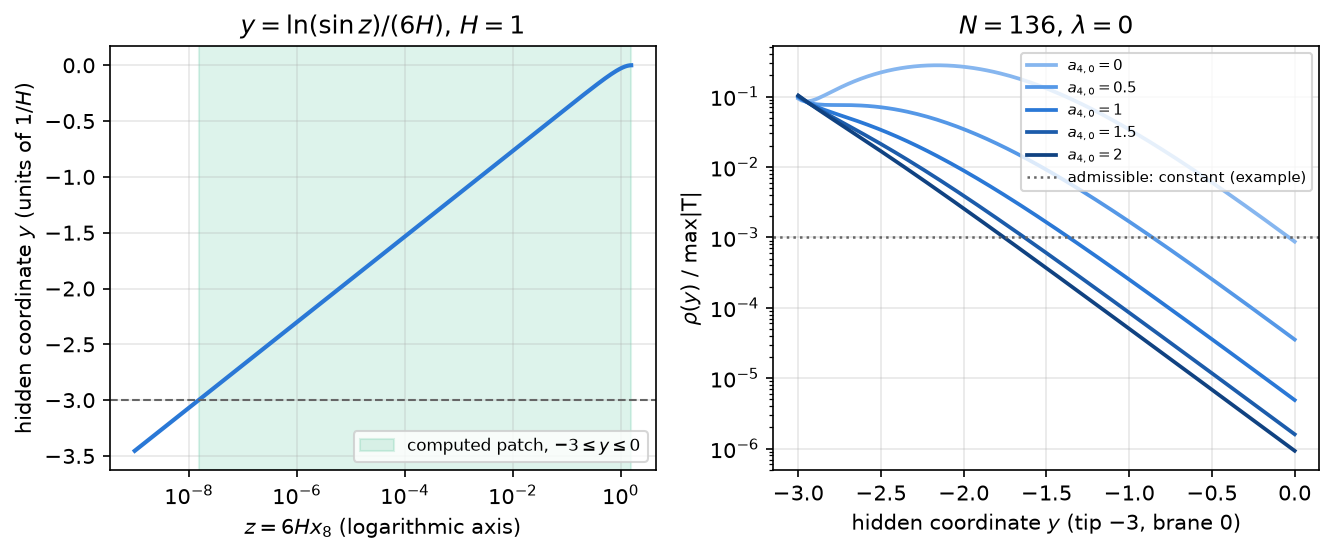

Figure 17a.1 saved as Revision/textbook/figures/17a_1_rho_profiles.png


In [6]:
SLICES = {"a00": 0.0, "a05": 0.5, "a10": 1.0, "a15": 1.5, "a20": 2.0}  # a4,0
SHADES = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]  # light -> dark
history136 = [f"N136_lam0_{tag}" for tag in SLICES]  # N = 136, lambda = 0
falls = [float(np.max(profiles[s]["rho"]) / np.min(profiles[s]["rho"]))
         for s in history136]  # how much rho changes along y, slice by slice
check(all(float(np.min(profiles[s]["rho"])) > 0.0 for s in history136),
      "N = 136, lambda = 0: rho is positive at every point of every slice")
z = np.logspace(-9, np.log10(np.pi / 2), 400)  # z from 1e-9 to pi/2
z_tip = float(np.arcsin(np.exp(-18.0)))  # where y = -3 (6 H y = -18 with H = 1)
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
left.plot(z, np.log(np.sin(z)) / 6.0, color="#2a78d6", lw=2.0)
left.axvspan(z_tip, np.pi / 2, color="#1baf7a", alpha=0.15,
             label="computed patch, $-3 \\leq y \\leq 0$")
left.axhline(-3.0, color="0.4", ls="--", lw=1.0)
left.set_xscale("log")
left.set_xlabel("$z = 6Hx_8$ (logarithmic axis)")
left.set_ylabel("hidden coordinate $y$ (units of $1/H$)")
left.set_title("$y = \\ln(\\sin z)/(6H)$, $H = 1$")
left.legend(loc="lower right", fontsize=8)
for shade, sid, a40 in zip(SHADES, history136, SLICES.values()):
    right.plot(y, profiles[sid]["rho"] / scale[sid], color=shade, lw=1.8,
               label=f"$a_{{4,0}} = {a40:g}$")
right.axhline(1e-3, color="0.4", ls=":", lw=1.2,
              label="admissible: constant (example)")
right.set_yscale("log")
right.set_xlabel("hidden coordinate $y$ (tip $-3$, brane $0$)")
right.set_ylabel("$\\rho(y)$ / max|T|")
right.set_title("$N = 136$, $\\lambda = 0$")
right.legend(fontsize=7, loc="upper right")
fig.tight_layout()
save_figure(fig, "rho_profiles",
            "Left: the hidden coordinate $y = \\ln(\\sin z)/(6H)$ against $z = 6Hx_8$ "
            "(logarithmic axis, $H = 1$); the shaded band is the computed patch from "
            "the tip cutoff $y = -3$ to the brane $y = 0$, which covers $z$ from "
            f"${z_tip / 1e-8:.1f} \\times 10^{{-8}}$ to $\\pi/2$. Right: the energy "
            "density $\\rho(y)$ of the Kohn-Sham state $N = 136$, $\\lambda = 0$ "
            "divided by the largest component of the state, at the five slices "
            "$a_{4,0} = 0$ to $2$ (logarithmic vertical axis). The largest value of "
            f"$\\rho$ is {min(falls):.0f} to {max(falls):.3g} times its smallest "
            "value, depending on the slice, while condition C1 of the field "
            "equations demands a horizontal line such as the dotted one.")

## 8. Condition C1: the source must not depend on $x_8$

The record measures the $x_8$ dependence of a state by the spread of its energy
density, $(\max_y\rho - \min_y\rho)/\max|T|$. For an admissible source this number
is $0$. The next cell computes it for the 70 nonzero states, finds the smallest
value, and checks that it is far above the record's tolerance $10^{-6}$ and that
the number and the state name printed by the record (six significant digits) are
exactly ours.

In [7]:
TOL = 1e-6  # the relative tolerance of the record
spread = {sid: float(np.max(profiles[sid]["rho"]) - np.min(profiles[sid]["rho"]))
          / scale[sid] for sid in nonzero}
smallest = min(spread, key=spread.get)  # the state that depends least on x8
largest = max(spread, key=spread.get)  # the state that depends most on x8
report("smallest spread of rho / max|T|", f"{spread[smallest]:.6g} ({smallest})")
report("largest spread of rho / max|T|", f"{spread[largest]:.6g} ({largest})")
detail = record_entry(SOURCE_REPORT, "ks_profiles_depend_on_x8")["detail"]
text = f">= {spread[smallest]:.6g} (smallest: {smallest})"  # as the record prints it
reproduces(all(value > TOL for value in spread.values()) and text in detail
           and "75 ground-state profiles" in detail
           and "70 with a nonzero" in detail,
           "C1 fails: every nonzero state depends on x8",
           SOURCE_REPORT, ["ks_profiles_depend_on_x8"])

RESULT smallest spread of rho / max|T| = 0.0497329 (N136_lamm2_a20)
RESULT largest spread of rho / max|T| = 0.995037 (N8_lamm1_a00)
PASS C1 fails: every nonzero state depends on x8
     reproduces Revision/field_equations_a4/reports/ks-source-conditions.json, check
    ks_profiles_depend_on_x8


The next cell draws the spread for all 75 states as a coloured table (a **heat
map**): one row per particle number and coupling, one column per slice. Grey cells
are the five states with $T = 0$. The colour scale is logarithmic. The helper
`describe` writes a state name as mathematics for the caption.

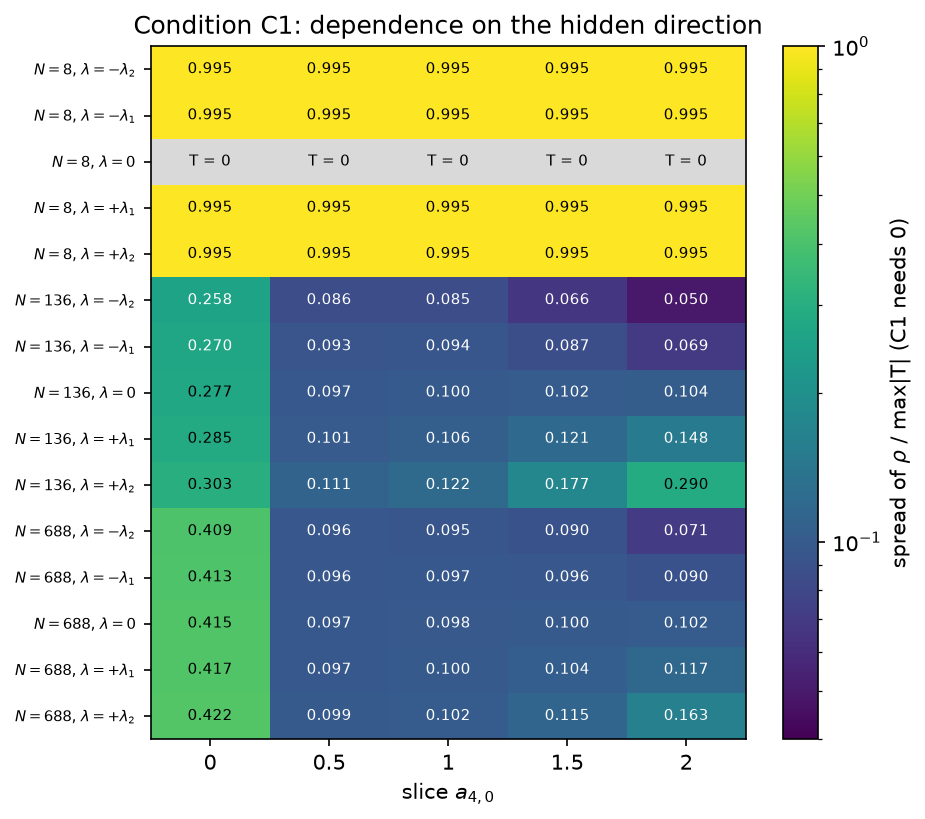

Figure 17a.2 saved as Revision/textbook/figures/17a_2_c1_map.png


In [8]:
from matplotlib.colors import LogNorm  # a logarithmic colour scale

TAGS = [("m2", "-\\lambda_2"), ("m1", "-\\lambda_1"), ("0", "0"),
        ("p1", "+\\lambda_1"), ("p2", "+\\lambda_2")]  # the couplings, in order
ROWS = [(n, tag, label) for n in (8, 136, 688) for tag, label in TAGS]


def describe(sid):
    """The state name N136_lamm2_a20 written as N = 136, lambda = -lambda_2, ..."""
    n, lam, slice_tag = sid.split("_")
    label = dict(TAGS)[lam[3:]]  # lam[3:] is m2, m1, 0, p1 or p2
    return (f"$N = {n[1:]}$, $\\lambda = {label}$, "
            f"$a_{{4,0}} = {SLICES[slice_tag]:g}$")


def state_table(values):
    """A 15 x 5 array of values[state] (NaN for the states with T = 0)."""
    table = np.full((len(ROWS), len(SLICES)), np.nan)
    for i, (n, tag, _) in enumerate(ROWS):
        for j, slice_tag in enumerate(SLICES):
            sid = f"N{n}_lam{tag}_{slice_tag}"
            if sid in values:
                table[i, j] = values[sid]
    return table


def draw_table(ax, table, norm, fmt):
    """Draw a state table as a heat map with the value written in every cell."""
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad("#d9d9d9")  # grey for NaN (the states with T = 0)
    image = ax.imshow(np.ma.masked_invalid(table), cmap=cmap, norm=norm,
                      aspect="auto")
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table[i, j]
            if np.isnan(value):
                ax.text(j, i, "T = 0", ha="center", va="center", fontsize=7)
                continue
            light = norm(value) > 0.6  # yellow-green cells: black text reads best
            ax.text(j, i, format(value, fmt), ha="center", va="center", fontsize=7,
                    color="black" if light else "white")
    ax.set_xticks(range(len(SLICES)), [f"{a:g}" for a in SLICES.values()])
    ax.set_yticks(range(len(ROWS)),
                  [f"$N = {n}$, $\\lambda = {label}$" for n, _, label in ROWS],
                  fontsize=7)
    ax.set_xlabel("slice $a_{4,0}$")
    ax.grid(False)
    return image


n8_spread = [value for sid, value in spread.items() if sid.startswith("N8_")]
fig, ax = plt.subplots(figsize=(6.4, 6.0))
image = draw_table(ax, state_table(spread), LogNorm(0.04, 1.0), ".3f")
fig.colorbar(image, ax=ax, label="spread of $\\rho$ / max|T| (C1 needs 0)")
ax.set_title("Condition C1: dependence on the hidden direction")
save_figure(fig, "c1_map",
            "The spread $(\\max_y \\rho - \\min_y \\rho)/\\max|T|$ of the energy "
            "density along the hidden coordinate for all 75 recorded Kohn-Sham "
            "ground states: rows are the particle numbers $N = 8, 136, 688$ with "
            "the five couplings, columns the slices $a_{4,0}$ (logarithmic colour "
            "scale, pure numbers). "
            "Condition C1 needs $0$ in every cell; the smallest value is "
            f"${spread[smallest]:.4f}$ ({describe(smallest)}), and the $N = 8$ "
            f"states, made of brane zero modes, have spreads of "
            f"${min(n8_spread):.3f}$ to ${max(n8_spread):.3f}$, almost the whole "
            "size of the tensor. Grey cells: the five states with no source at all.")

## 9. Condition C2 point by point: $p_3 + p_t = 2p_8$

The next cell forms the **violation profile** $V(y) = p_3 + p_t - 2p_8$ of every
nonzero state (an admissible source has $V = 0$ at every $y$) and its size
$\max_y|V|/\max|T|$. It checks that the size is far from zero for every state and
that the smallest and largest values, with their states, are those of the record.

In [9]:
violation = {sid: profiles[sid]["p3"] + profiles[sid]["p_t"]
             - 2.0 * profiles[sid]["p8"] for sid in nonzero}  # V(y)
size = {sid: float(np.max(np.abs(violation[sid]))) / scale[sid] for sid in nonzero}
low = min(size, key=size.get)  # the state closest to C2
high = max(size, key=size.get)  # the state farthest from C2
report("smallest max|V| / max|T|", f"{size[low]:.6g} ({low})")
report("largest max|V| / max|T|", f"{size[high]:.6g} ({high})")
detail = record_entry(SOURCE_REPORT, "ks_profiles_violate_algebraic_condition")[
    "detail"]
text = f"between {size[low]:.6g} ({low}) and {size[high]:.6g} ({high})"
reproduces(all(value > TOL for value in size.values()) and text in detail,
           "C2 fails point by point for every nonzero state",
           SOURCE_REPORT, ["ks_profiles_violate_algebraic_condition"])

RESULT smallest max|V| / max|T| = 2.09192 (N136_lamp2_a20)
RESULT largest max|V| / max|T| = 3.99006 (N8_lamm1_a00)
PASS C2 fails point by point for every nonzero state
     reproduces Revision/field_equations_a4/reports/ks-source-conditions.json, check
    ks_profiles_violate_algebraic_condition


The next cell draws the violation profiles $V(y)/\max|T|$ of the states with
$\lambda = 0$ for $N = 136$ (left) and $N = 688$ (right), at the five slices. The
vertical axis is **symmetric logarithmic**: logarithmic for large positive and
negative values, linear between $-10^{-7}$ and $10^{-7}$, so that both signs and
seven orders of magnitude are visible. The dashed line is the value $0$ that C2
demands. Before drawing, the cell counts how often each plotted profile changes
its sign between neighbouring grid points, and how large $|V|$ is at the tip and
at the brane; the caption quotes these numbers.

sign changes of the ten plotted profiles: [1]
PASS each plotted V(y) changes sign exactly once and is nonzero at the brane


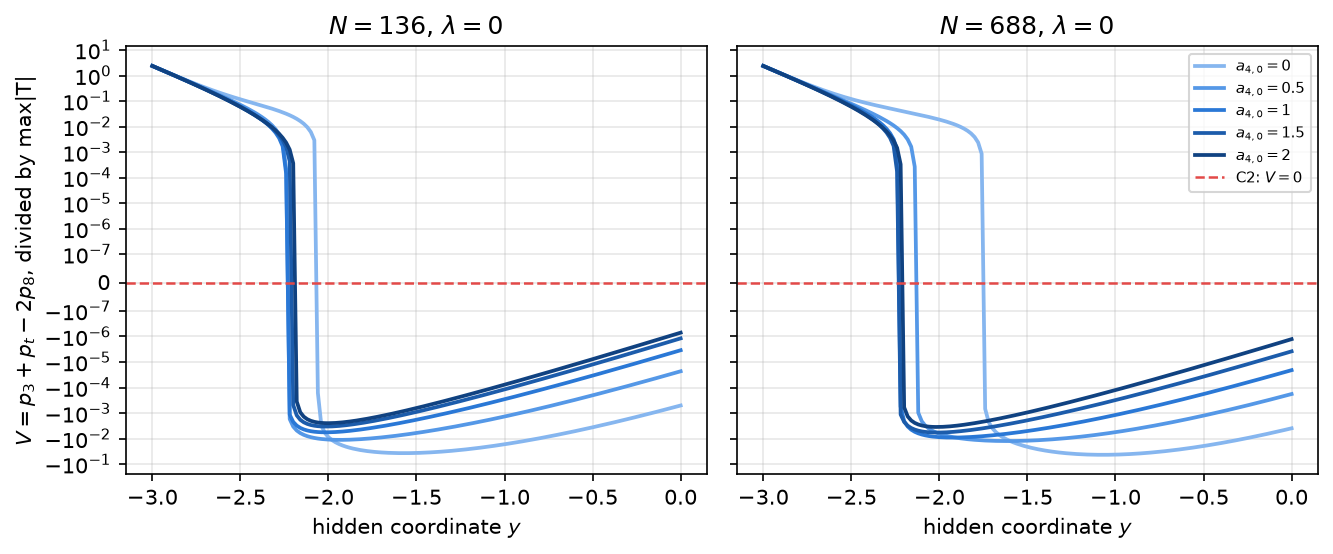

Figure 17a.3 saved as Revision/textbook/figures/17a_3_violation_profiles.png


In [10]:
plotted = [f"N{n}_lam0_{tag}" for n in (136, 688) for tag in SLICES]
signs = {sid: np.sign(violation[sid]) for sid in plotted}  # +1, -1 (or 0)
changes = {sid: int(np.sum(signs[sid][1:] * signs[sid][:-1] < 0)) for sid in plotted}
at_tip = [abs(float(violation[sid][0])) / scale[sid] for sid in plotted]
at_brane = [abs(float(violation[sid][-1])) / scale[sid] for sid in plotted]
say(f"sign changes of the ten plotted profiles: {sorted(set(changes.values()))}")
check(all(count == 1 for count in changes.values())
      and min(at_brane) > 0.0,
      "each plotted V(y) changes sign exactly once and is nonzero at the brane")
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.8), sharey=True)
for ax, n in zip(axes, (136, 688)):
    for shade, (tag, a40) in zip(SHADES, SLICES.items()):
        sid = f"N{n}_lam0_{tag}"
        ax.plot(y, violation[sid] / scale[sid], color=shade, lw=1.8,
                label=f"$a_{{4,0}} = {a40:g}$")
    ax.axhline(0.0, color="#e34948", ls="--", lw=1.2, label="C2: $V = 0$")
    ax.set_yscale("symlog", linthresh=1e-7)
    ax.set_xlabel("hidden coordinate $y$")
    ax.set_title(f"$N = {n}$, $\\lambda = 0$")
axes[0].set_ylabel("$V = p_3 + p_t - 2p_8$, divided by max|T|")
axes[1].legend(fontsize=7, loc="upper right")
fig.tight_layout()
save_figure(fig, "violation_profiles",
            "The violation profiles $V(y) = p_3 + p_t - 2p_8$ of the Kohn-Sham ground "
            "states with $\\lambda = 0$, divided by the largest component of each "
            "state, for $N = 136$ (left) and $N = 688$ (right) at the five slices "
            "$a_{4,0}$ (horizontal axis: the hidden coordinate $y$; vertical axis "
            "symmetric logarithmic, linear between $-10^{-7}$ and $10^{-7}$). "
            "Condition C2 of the field equations demands the dashed line $V = 0$; "
            f"instead $|V|$ is {min(at_tip):.2f} to {max(at_tip):.2f} times max|T| "
            "at the tip, every profile changes sign exactly once, and at the brane "
            f"$|V|$/max|T| is still between ${min(at_brane):.1e}$ and "
            f"${max(at_brane):.1e}$, small but not zero.")

The next cell draws the size $\max_y|V|/\max|T|$ for all 75 states as a heat map,
in the same layout as the map of C1 (linear colour scale).

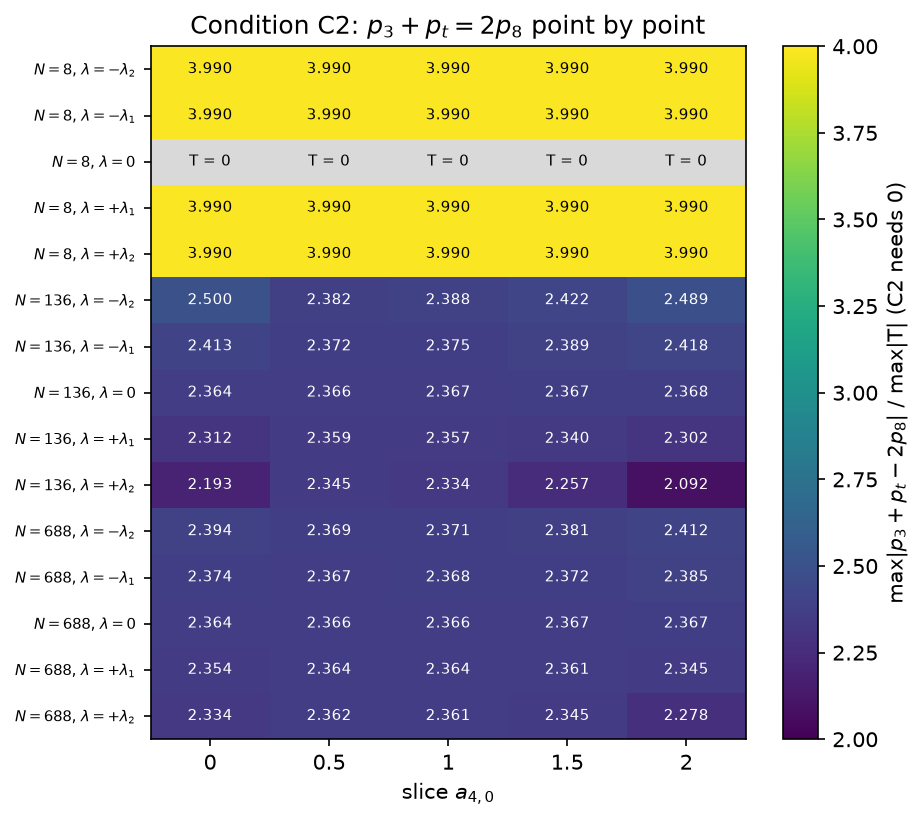

Figure 17a.4 saved as Revision/textbook/figures/17a_4_c2_map.png


In [11]:
from matplotlib.colors import Normalize  # a linear colour scale

fig, ax = plt.subplots(figsize=(6.4, 6.0))
image = draw_table(ax, state_table(size), Normalize(2.0, 4.0), ".3f")
fig.colorbar(image, ax=ax, label="max$|p_3 + p_t - 2p_8|$ / max|T| (C2 needs 0)")
ax.set_title("Condition C2: $p_3 + p_t = 2p_8$ point by point")
save_figure(fig, "c2_map",
            "The size $\\max_y|p_3 + p_t - 2p_8|/\\max|T|$ of the violation of "
            "condition C2 for all 75 recorded Kohn-Sham ground states (rows: particle "
            "number and coupling; columns: the slice $a_{4,0}$; linear colour scale, "
            "pure numbers). C2 needs $0$; every nonzero state violates it by "
            f"${size[low]:.2f}$ to ${size[high]:.2f}$ times its largest component. "
            "The $N = 8$ states, made of brane zero modes, have the same value at "
            "every slice; grey cells: no source.")

## 10. A worked example: three points of one state

The record illustrates the failure with the state $N = 136$, $\lambda = 0$,
$a_{4,0} = 1$ at three points: next to the tip ($y = -3$), in the middle
($y = -1.5$) and at the brane ($y = 0$). The next cell takes the grid point nearest
to each, prints the four components and $V$ with six significant digits, and checks
that the record prints exactly the same text. (A printed `-0` is the number zero
stored with a minus sign; it equals $0$.)

In [12]:
example = profiles["N136_lam0_a10"]
POINTS = (-3.0, -1.5, 0.0)  # tip, middle, brane
detail = record_entry(SOURCE_REPORT, "ks_profiles_violate_algebraic_condition")[
    "detail"]
rows = []
for target in POINTS:
    i = int(np.argmin(np.abs(example["y"] - target)))  # nearest grid point
    values = {c: float(example[c][i]) for c in ("y",) + COLUMNS}
    values["V"] = values["p3"] + values["p_t"] - 2.0 * values["p8"]
    rows.append(values)
    text = (f"y = {values['y']:.6g}: rho = {values['rho']:.6g}, "
            f"p3 = {values['p3']:.6g}, p_t = {values['p_t']:.6g}, "
            f"p8 = {values['p8']:.6g}, p3 + p_t - 2 p8 = {values['V']:.6g}")
    say(text)
    values["in_record"] = text in detail  # the record prints the same text?
reproduces(all(r["in_record"] for r in rows) and all(r["V"] != 0 for r in rows),
           "the three example points of N136_lam0_a10 equal the record",
           SOURCE_REPORT, ["ks_profiles_violate_algebraic_condition"])

y = -3: rho = 43.0702, p3 = 158.268, p_t = -0, p8 = -431.733, p3 + p_t - 2 p8 = 1021.73
y = -1.5: rho = 0.707818, p3 = 0.498835, p_t = 0, p8 = 0.643324, p3 + p_t - 2 p8 =
    -0.787813
y = -0: rho = 0.00211576, p3 = 0.000391237, p_t = -0, p8 = 0.000942049, p3 + p_t - 2 p8 =
    -0.00149286
PASS the three example points of N136_lam0_a10 equal the record
     reproduces Revision/field_equations_a4/reports/ks-source-conditions.json, check
    ks_profiles_violate_algebraic_condition


The next cell draws, for each of the three points, the two sides of C2 as bars:
$p_3 + p_t$ and $2p_8$. C2 demands two bars of equal height at every point.

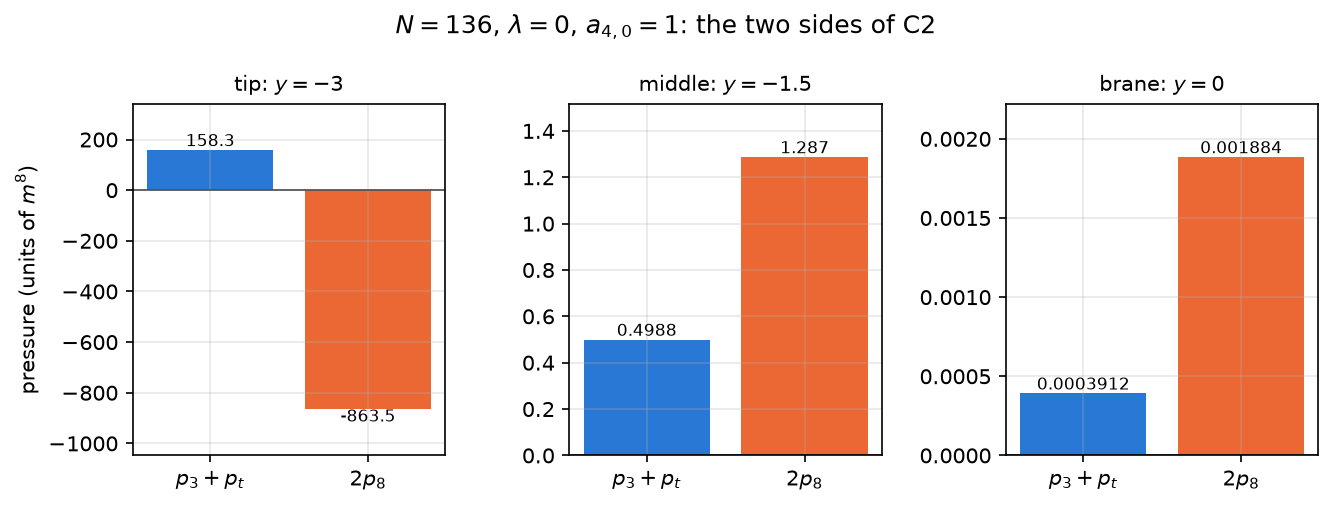

Figure 17a.5 saved as Revision/textbook/figures/17a_5_three_points.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(9.0, 3.4))
for ax, values, where in zip(axes, rows, ("tip", "middle", "brane")):
    sides = [values["p3"] + values["p_t"], 2.0 * values["p8"]]
    bars = ax.bar(["$p_3 + p_t$", "$2p_8$"], sides, color=["#2a78d6", "#eb6834"])
    for bar, value in zip(bars, sides):
        ax.annotate(f"{value:.4g}", (bar.get_x() + bar.get_width() / 2, value),
                    ha="center", va="bottom" if value >= 0 else "top", fontsize=8)
    ax.axhline(0.0, color="0.3", lw=0.8)
    ax.set_title(f"{where}: $y = {values['y'] + 0.0:g}$", fontsize=10)
    ax.margins(y=0.18)
axes[0].set_ylabel("pressure (units of $m^8$)")
fig.suptitle("$N = 136$, $\\lambda = 0$, $a_{4,0} = 1$: the two sides of C2")
fig.tight_layout()
tip, middle, brane = rows
factors = [2.0 * r["p8"] / (r["p3"] + r["p_t"]) for r in (middle, brane)]
save_figure(fig, "three_points",
            "The two sides of condition C2, $p_3 + p_t$ (blue) and $2p_8$ (orange), "
            "of the Kohn-Sham state $N = 136$, $\\lambda = 0$, $a_{4,0} = 1$ at the "
            "tip $y = -3$, in the middle $y = -1.5$ and at the brane $y = 0$ "
            "(vertical axes: proper pressure in units of $m^8$, each panel with its "
            "own scale). C2 demands equal bars; near the tip the two sides even have "
            f"opposite signs (${tip['p3'] + tip['p_t']:.1f}$ against "
            f"${2.0 * tip['p8']:.1f}$), in the middle $2p_8$ is {factors[0]:.2f} "
            f"times $p_3 + p_t$ and at the brane {factors[1]:.2f} times.")

## 11. Condition C2 after integration over $x_8$

Could an average over the hidden direction rescue C2? A source that is averaged
over $x_8$ (a "dimensionally reduced" source) would need
$\int p_3 + \int p_t = 2\int p_8$, the integrals taken over the patch with the
proper-volume weight. The next cell computes the ratio
$(\int p_3 + \int p_t)/(2\int p_8)$ from the record's table of integrals for every
nonzero state. C2 would need the ratio $1$.

In [14]:
def integral(sid, column):
    """The integral 2 Vol_7 int e^{6Hy} X dy of column X from the record's table."""
    return float(integrals[sid][column])


ratio = {sid: (integral(sid, "int_p3") + integral(sid, "int_p_t"))
         / (2.0 * integral(sid, "int_p8"))
         for sid in nonzero if integral(sid, "int_p8") != 0.0}
closest = min(ratio, key=lambda sid: abs(ratio[sid] - 1.0))
report("ratio closest to 1", f"{ratio[closest]:.6g} ({closest})")
report("range of the ratio", f"{min(ratio.values()):.4f} to {max(ratio.values()):.4f}")
history_text = ", ".join(f"{sid}: {ratio[sid]:.6g}" for sid in
                         ("N136_lam0_a00", "N136_lam0_a10", "N136_lam0_a20"))
say("the history N = 136, lambda = 0: " + history_text)
detail = record_entry(SOURCE_REPORT, "ks_integrals_violate_algebraic_condition")[
    "detail"]
reproduces(len(ratio) == len(nonzero)
           and all(abs(r - 1.0) > TOL for r in ratio.values())
           and f"(closest to 1: {ratio[closest]:.6g} at {closest})" in detail
           and history_text in detail,
           "C2 fails also after integration over x8, for every nonzero state",
           SOURCE_REPORT, ["ks_integrals_violate_algebraic_condition"])

RESULT ratio closest to 1 = 0.414328 (N688_lamm2_a00)
RESULT range of the ratio = 0.1072 to 0.4143
the history N = 136, lambda = 0: N136_lam0_a00: 0.339767, N136_lam0_a10: 0.25969,
    N136_lam0_a20: 0.239714
PASS C2 fails also after integration over x8, for every nonzero state
     reproduces Revision/field_equations_a4/reports/ks-source-conditions.json, check
    ks_integrals_violate_algebraic_condition


The next cell draws the integrated ratio against the slice $a_{4,0}$ for every
particle number (colour) and coupling (line style and marker). The red dashed line
is the value $1$ that an averaged source would need.

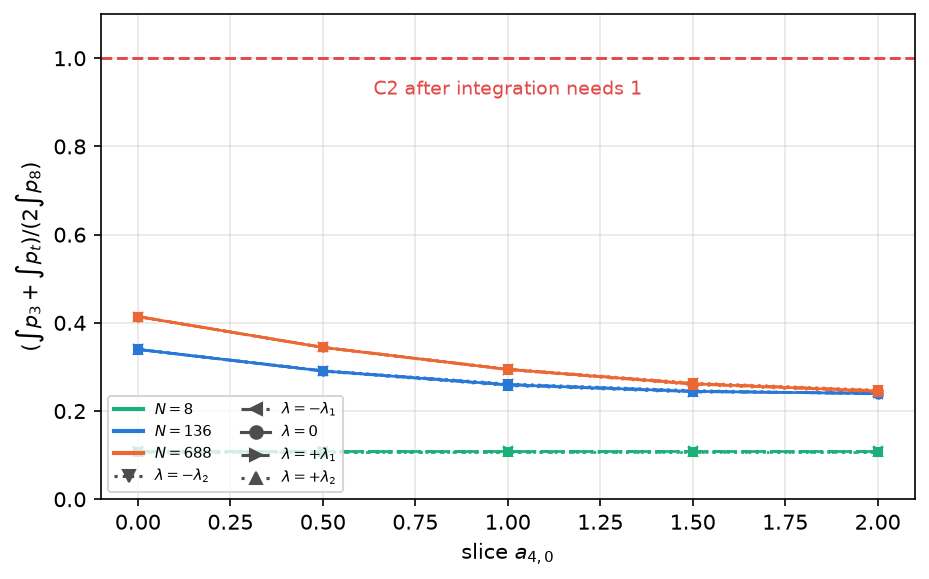

Figure 17a.6 saved as Revision/textbook/figures/17a_6_integrated_ratio.png


In [15]:
N_COLOURS = {8: "#1baf7a", 136: "#2a78d6", 688: "#eb6834"}
STYLES = {"m2": ("v", ":"), "m1": ("<", "-."), "0": ("o", "-"),
          "p1": (">", "--"), "p2": ("^", (0, (1, 3)))}  # marker, line style
fig, ax = plt.subplots()
for n, tag, label in ROWS:
    ids = [f"N{n}_lam{tag}_{s}" for s in SLICES]
    if ids[0] not in ratio:
        continue  # N = 8, lambda = 0: no source
    marker, style = STYLES[tag]
    ax.plot(list(SLICES.values()), [ratio[sid] for sid in ids], marker=marker,
            ls=style, color=N_COLOURS[n], lw=1.3, ms=4)
ax.axhline(1.0, color="#e34948", ls="--", lw=1.4)
ax.text(1.0, 0.95, "C2 after integration needs 1", color="#e34948", ha="center",
        va="top", fontsize=9)
for n, colour in N_COLOURS.items():
    ax.plot([], [], color=colour, lw=2.0, label=f"$N = {n}$")
for tag, label in TAGS:
    marker, style = STYLES[tag]
    ax.plot([], [], color="0.3", marker=marker, ls=style, label=f"$\\lambda = {label}$")
ax.set_xlabel("slice $a_{4,0}$")
ax.set_ylabel("$(\\int p_3 + \\int p_t) / (2\\int p_8)$")
ax.set_ylim(0.0, 1.1)
ax.legend(fontsize=7, ncol=2, loc="lower left")
save_figure(fig, "integrated_ratio",
            "The ratio $(\\int p_3 + \\int p_t)/(2\\int p_8)$ of the pressures "
            "integrated over the patch with the proper-volume weight, for every "
            "nonzero recorded Kohn-Sham state, against the slice $a_{4,0}$ "
            "(colours: particle number; line styles and markers: coupling; pure "
            "numbers). A source averaged over $x_8$ would need the value $1$ (red "
            "dashed line); the states lie between "
            f"${min(ratio.values()):.3f}$ and ${max(ratio.values()):.3f}$, so even "
            "the average violates condition C2.")

## 12. Condition C3: the linear member along the history

The Kohn-Sham history is the linear member $a_4 = AHx_4$ with $A = 1$. For it the
field equations need $p_3 = p_t = p_8$ and a constant $\rho$ (C3). The record tests
this on the integrals of the six states $N = 136$ and $N = 688$ with $\lambda = 0$
at the slices $0$, $1$ and $2$. The next cell prints their integrated $\rho$,
$p_3$, $p_t$, checks that $\rho$ changes from slice to slice and that $p_3 \ne p_t$
(with the record's tolerance), and that the record prints the same numbers.

In [16]:
HISTORY = ["N136_lam0_a00", "N136_lam0_a10", "N136_lam0_a20",
           "N688_lam0_a00", "N688_lam0_a10", "N688_lam0_a20"]
pieces = []
for sid in HISTORY:
    r, p3, pt = (integral(sid, c) for c in ("int_rho", "int_p3", "int_p_t"))
    pieces.append(f"{sid}: int rho = {r:.6g}, int p3 = {p3:.6g}, int p_t = {pt:.6g}")
    say(pieces[-1])
rho_constant = all(
    abs(integral(a, "int_rho") - integral(b, "int_rho"))
    <= TOL * abs(integral(a, "int_rho"))
    for a, b in (("N136_lam0_a00", "N136_lam0_a10"),
                 ("N688_lam0_a00", "N688_lam0_a10")))
p_equal = all(abs(integral(s, "int_p3") - integral(s, "int_p_t"))
              <= TOL * max(abs(integral(s, "int_p3")), 1.0) for s in HISTORY)
detail = record_entry(SOURCE_REPORT, "ks_history_is_a_prescribed_background")[
    "detail"]
reproduces(not rho_constant and not p_equal and "; ".join(pieces) in detail,
           "C3 fails: along the history rho changes and p3 differs from p_t",
           SOURCE_REPORT, ["ks_history_is_a_prescribed_background"])

N136_lam0_a00: int rho = 80.2822, int p3 = 23.8133, int p_t = 0
N136_lam0_a10: int rho = 32.3841, int p3 = 10.0397, int p_t = 0
N136_lam0_a20: int rho = 12.4451, int p3 = 4.06205, int p_t = 0
N688_lam0_a00: int rho = 680.441, int p3 = 199.305, int p_t = 0
N688_lam0_a10: int rho = 279.425, int p3 = 84.3387, int p_t = 0
N688_lam0_a20: int rho = 110.387, int p3 = 35.1354, int p_t = 0
PASS C3 fails: along the history rho changes and p3 differs from p_t
     reproduces Revision/field_equations_a4/reports/ks-source-conditions.json, check
    ks_history_is_a_prescribed_background


The next cell draws the four integrated components of the states with
$\lambda = 0$ at all five slices, for $N = 136$ (left) and $N = 688$ (right). C3
would need a horizontal $\rho$ line and the three pressure lines on top of each
other. Without interaction $p_t = e_{int} = 0$ exactly (the interaction energy
density $e_{int}$ is the only extra-time pressure of the good sector), so the $p_t$
line lies on the axis.

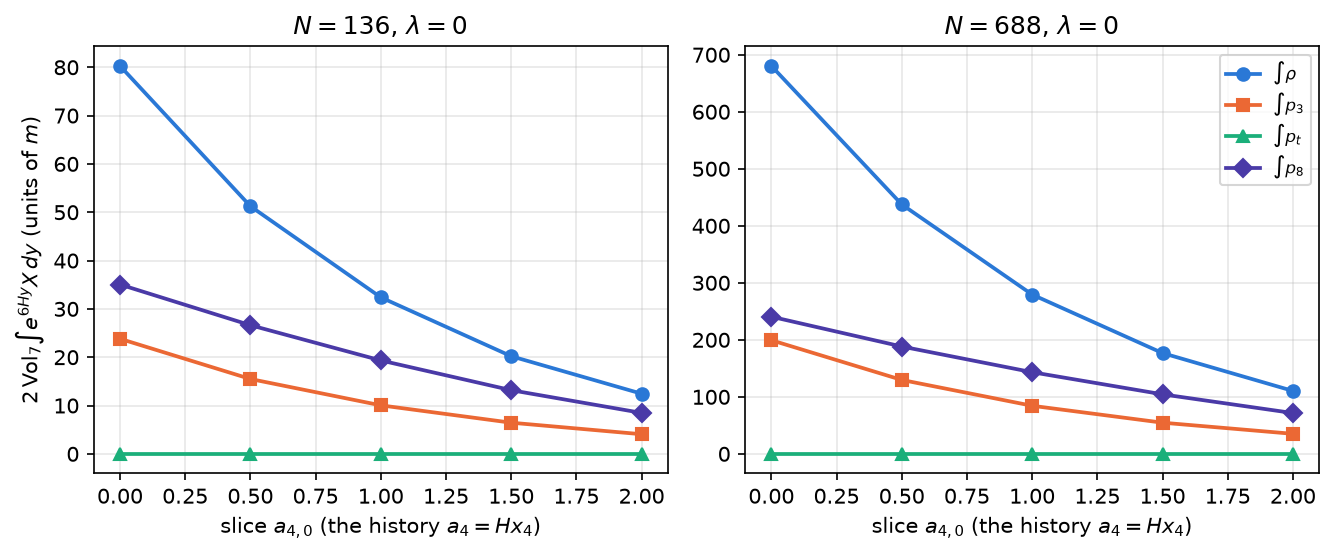

Figure 17a.7 saved as Revision/textbook/figures/17a_7_history_integrals.png


In [17]:
PARTS = [("int_rho", "$\\int\\rho$", "#2a78d6", "o"),
         ("int_p3", "$\\int p_3$", "#eb6834", "s"),
         ("int_p_t", "$\\int p_t$", "#1baf7a", "^"),
         ("int_p8", "$\\int p_8$", "#4a3aa7", "D")]
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.8))
for ax, n in zip(axes, (136, 688)):
    ids = [f"N{n}_lam0_{s}" for s in SLICES]
    for column, label, colour, marker in PARTS:
        ax.plot(list(SLICES.values()), [integral(sid, column) for sid in ids],
                color=colour, marker=marker, lw=1.8, label=label)
    ax.set_xlabel("slice $a_{4,0}$ (the history $a_4 = Hx_4$)")
    ax.set_title(f"$N = {n}$, $\\lambda = 0$")
axes[0].set_ylabel("$2\\,\\mathrm{Vol}_7\\int e^{6Hy} X\\,dy$ (units of $m$)")
axes[1].legend(fontsize=8)
fig.tight_layout()
drop = [integral(f"N{n}_lam0_a00", "int_rho") / integral(f"N{n}_lam0_a20", "int_rho")
        for n in (136, 688)]
save_figure(fig, "history_integrals",
            "The energy density and the three pressures of the Kohn-Sham states with "
            "$\\lambda = 0$, integrated over the patch with the proper-volume weight, "
            "at the five slices of the history $a_4 = Hx_4$ (left $N = 136$, right "
            "$N = 688$; vertical axis in units of $m$ with $H = 1$). The linear member "
            "needs a constant $\\rho$ and equal pressures (condition C3); instead "
            f"$\\int\\rho$ falls by a factor of {drop[0]:.2f} ($N = 136$) and "
            f"{drop[1]:.2f} ($N = 688$) from $a_{{4,0}} = 0$ to $2$, $\\int p_3$ stays "
            "above $\\int p_t = 0$, and $\\int p_8$ is different again.")

The states $N = 8$ need a separate remark. They consist of the eight brane zero
modes, which have zero 3-momentum $k$. The slice $a_{4,0}$ enters the Kohn-Sham
equations only through the redshifted momentum $k e^{-a_{4,0}}$, while the proper
box stays the same (the exact rescaling identity of the Kohn-Sham record), so for
$k = 0$ nothing changes: these states are the same at every slice. The next cell
confirms that their profiles are identical at all five slices and that they have
$p_3 = p_t$; so they satisfy the part "constant $\rho$ and $p_3 = p_t$" of C3. They
are nevertheless not admissible: $p_8$ differs from $p_3$, and they fail C1 and C2
(the maps of sections 8 and 9).

In [18]:
same, p3_equals_pt, p8_differs = True, True, True
for tag in ("m2", "m1", "p1", "p2"):
    first = profiles[f"N8_lam{tag}_a00"]
    for slice_tag in SLICES:
        prof = profiles[f"N8_lam{tag}_{slice_tag}"]
        same = same and all(np.array_equal(prof[c], first[c]) for c in COLUMNS)
    p3_equals_pt = p3_equals_pt and np.array_equal(first["p3"], first["p_t"])
    p8_differs = p8_differs and float(np.max(np.abs(first["p8"] - first["p3"]))) > 0
say("N = 8, lambda = +lambda_1: int p3 = "
    f"{integral('N8_lamp1_a00', 'int_p3'):.6g}, int p8 = "
    f"{integral('N8_lamp1_a00', 'int_p8'):.6g}")
check(same and p3_equals_pt and p8_differs,
      "N = 8: the same state at every slice, p3 = p_t, but p8 differs from p3")

N = 8, lambda = +lambda_1: int p3 = -0.000977659, int p8 = -0.00889138
PASS N = 8: the same state at every slice, p3 = p_t, but p8 differs from p3


## 13. The states with no source at all

Five states have $T = 0$ at every point: $N = 8$ with $\lambda = 0$ (zero modes
with zero energy and no interaction). Is "no source" admissible? In Einstein
gravity ($\alpha_1 = 1$, $\alpha_2 = \alpha_3 = 0$) the record's $x_4$ and $x_8$
equations read $3a_4'^2 + 21H^2 + \Lambda = -\kappa\rho$ and
$-3a_4'^2 + 15H^2 + \Lambda = \kappa p_8$. With $\rho = p_8 = 0$, subtracting the
second from the first gives $6a_4'^2 + 6H^2 = 0$, impossible for real $a_4'$ and
$H > 0$: the left side is a square times 6 plus a positive number. The next cell
repeats this with sympy, from the record's text of the two equations (sympy is told
that $a_4'$ is real and $H$ positive, and it decides that the difference is
positive), and checks the list of zero states against the record.

In [19]:
kappa, rho, p8, Lam = sp.symbols("kappa rho p8 Lam", real=True)
NAMES.update({"kappa": kappa, "rho": rho, "p8": p8, "Lam": Lam})


def equation(text):
    """An equation 'left == right' of the record as the expression left - right."""
    left, right = text.split("==")
    return parse(left) - parse(right)


einstein = equations["einstein"]
x4_equation = equation(einstein["constraint_x4"]["input"]).subs({rho: 0})
x8_equation = equation(einstein["hidden_x8"]["input"]).subs({p8: 0})
difference = sp.expand(x4_equation - x8_equation)  # Lambda cancels
say(f"x4 equation minus x8 equation with rho = p8 = 0: {difference} = 0")
say(f"is the left side positive for real a4' and H > 0? {difference.is_positive}")
reproduces(difference == 6 * ad1 ** 2 + 6 * H ** 2 and difference.is_positive is True,
           "Einstein gravity: no source at all (T = 0) has no solution for H > 0",
           WL_A4, ["einstein_no_vacuum_solution"])
detail = record_entry(SOURCE_REPORT, "ks_zero_source_states_listed")["detail"]
reproduces(", ".join(zero) in detail and f"{len(zero)} states" in detail,
           "the five states with T = 0 are those listed by the record",
           SOURCE_REPORT, ["ks_zero_source_states_listed"])

x4 equation minus x8 equation with rho = p8 = 0: 6*H**2 + 6*ad1**2 = 0
is the left side positive for real a4' and H > 0? True
PASS Einstein gravity: no source at all (T = 0) has no solution for H > 0
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    einstein_no_vacuum_solution
PASS the five states with T = 0 are those listed by the record
     reproduces Revision/field_equations_a4/reports/ks-source-conditions.json, check
    ks_zero_source_states_listed


## 14. The last check

The last cell checks that the seven figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [20]:
names = ["rho_profiles", "c1_map", "violation_profiles", "c2_map", "three_points",
         "integrated_ratio", "history_integrals"]
paths = [output_file(f"{FIGURE_FOLDER}/17a_{k}_{name}.png")
         for k, name in enumerate(names, 1)]
check(all(path.is_file() for path in paths),
      "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 16 CHECKS PASSED (notebook 17a)


## 15. What this notebook showed

- PROVED (read from the a4 record and re-derived here with sympy): the left-hand
  sides of the Einstein-Lovelock equations of the author's metric are free of
  $x_8$ and have no $x_4x_8$ component (C1), obey
  $E^{x_1}{}_{x_1} + E^{x_5}{}_{x_5} = 2E^{x_8}{}_{x_8}$ for every order (C2:
  $p_3 + p_t = 2p_8$), and for the linear member need equal pressures and a
  constant energy density (C3).
- COMPUTED (the 75 recorded Kohn-Sham ground states; every number of the five
  checks of the record `ks-source-conditions.json` reproduced): every nonzero
  state depends on $x_8$ (the spread of $\rho$ is at least $0.0497$ of max|T|),
  violates C2 point by point (by $2.09$ to $3.99$ times max|T|) and after
  integration over $x_8$ (ratios between $0.107$ and $0.414$ instead of $1$), and
  along the history $\rho$ changes and $p_3 \ne p_t$. The $N = 8$ states do not
  change along the history, but they too fail C1 and C2.
- PROVED (Einstein gravity): $T = 0$ is not a solution for $H > 0$, so the five
  states without a source are not admissible either.
- Hence no recorded Kohn-Sham state is an admissible source. The Kohn-Sham history
  $a_4 = Hx_4$ is a PRESCRIBED BACKGROUND (ASSUMED, not solved for): the gas is a
  test field without back-reaction, and energies, pressures and equations of state
  computed along it are not consequences of the coupled field equations.
- NOT shown: that no state of dirac16complex could ever be a source of the
  author's metric, or what metric the Kohn-Sham gas would produce with
  back-reaction (OPEN).